# NLP Lab Assessment

## Submitted by Chaitanya Jindal

#### Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from wordcloud import WordCloud

import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

### Task 1: Load the Dataset

In [2]:
df = pd.read_csv('IMDB_Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [4]:
print(f"Shape of the dataset: {df.shape}")
print("\nClass Distribution")
print(df["sentiment"].value_counts())

Shape of the dataset: (50000, 2)

Class Distribution
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


### Task 2: Exploratory Data Analysis (EDA)

##### 1. Check missing values

In [5]:
print(f"Number of null values in each column:\n{df.isnull().sum()}")

Number of null values in each column:
review       0
sentiment    0
dtype: int64


##### 2. Remove duplicate records

In [6]:
print("Before:", df.shape)

df.drop_duplicates(inplace=True)

print("After:", df.shape)

Before: (50000, 2)
After: (49582, 2)


##### 3. Find
- average review length 
- longest review 
- shortest review

In [7]:
df["review_length"] = df["review"].apply(len)

print(f"Average Length: {df['review_length'].mean()}")
print(f"Longest Review Length: {df['review_length'].max()}")
print(f"Shortest Review Length: {df['review_length'].min()}")

Average Length: 1310.5682304061959
Longest Review Length: 13704
Shortest Review Length: 32


##### 4. Plot
- sentiment distribution
- histogram of review lengths
- word cloud for positive reviews
- word cloud for negative reviews.

C:\Users\ChaitanyaJindal\AppData\Local\Temp\ipykernel_11768\404495310.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


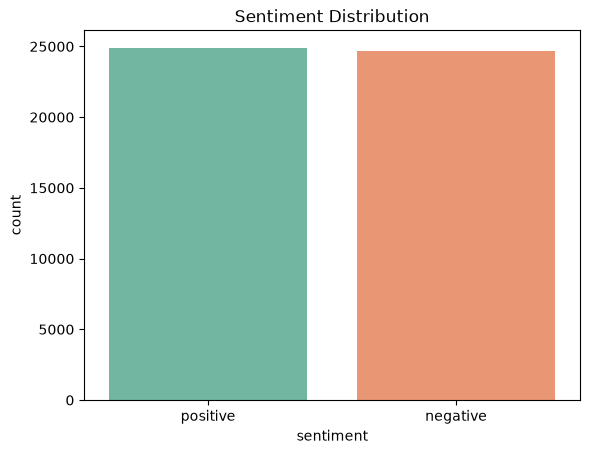

In [8]:
sns.countplot(
    data=df,
    x="sentiment",
    palette="Set2"
)

plt.title("Sentiment Distribution")
plt.show()

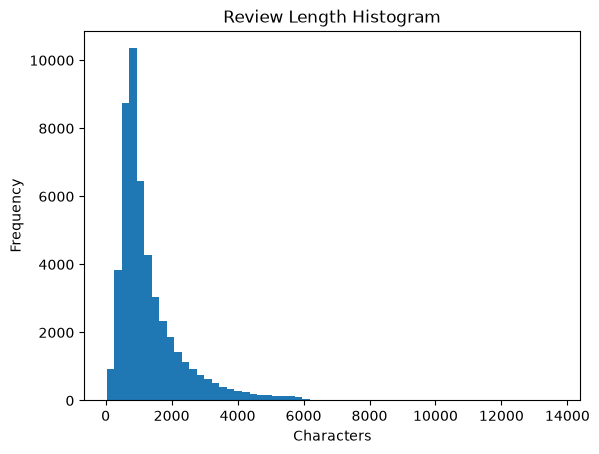

In [9]:
plt.hist(df["review_length"], bins=60)

plt.title("Review Length Histogram")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

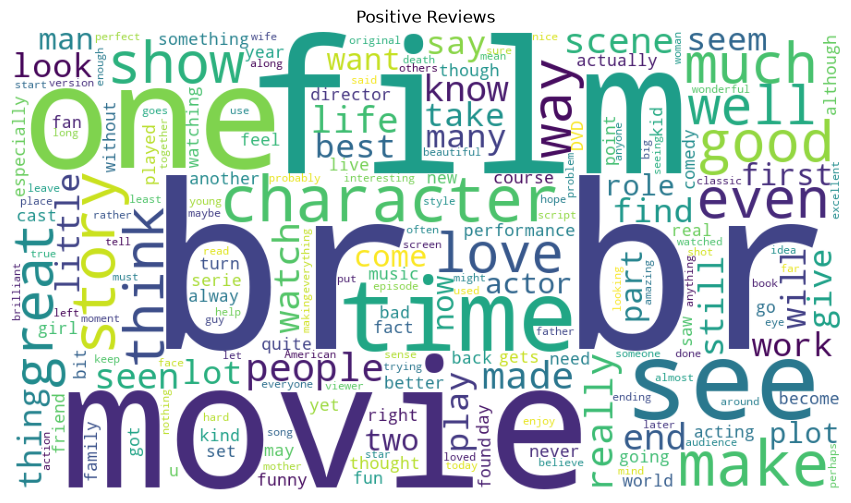

In [10]:
positive_text = " ".join(df[df.sentiment=="positive"]["review"])

wc = WordCloud(
    width=900,
    height=500,
    background_color="white"
)

plt.figure(figsize=(12,6))
plt.imshow(wc.generate(positive_text))
plt.axis("off")
plt.title("Positive Reviews")
plt.show()

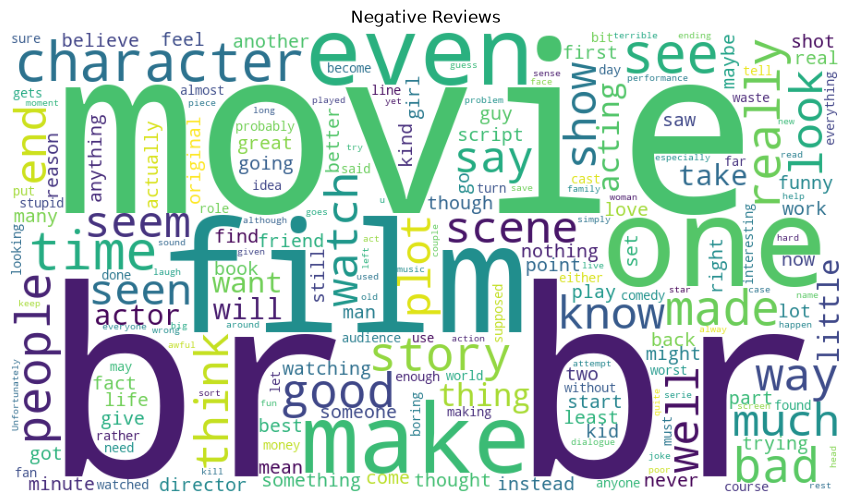

In [11]:
negative_text = " ".join(df[df.sentiment=="negative"]["review"])

wc = WordCloud(
    width=900,
    height=500,
    background_color="white"
)

plt.figure(figsize=(12,6))
plt.imshow(wc.generate(negative_text))
plt.axis("off")
plt.title("Negative Reviews")
plt.show()

### Task 3: Text Pre-processing

##### 1. Convert text to lowercase

In [12]:
sample = df["review"].iloc[0]
print(f"Original: {sample}")
lower = sample.lower()
print(f"Lowercase: {lower}")

Original: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due 

##### 2. Remove punctuation

In [13]:
no_punc = lower.translate(
    str.maketrans("", "", string.punctuation)
)

print(f"No Punctuation: {no_punc}")

No Punctuation: one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked they are right as this is exactly what happened with mebr br the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordbr br it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awaybr br i would say the main appeal of the show is due to the fact that it goes where other shows 

##### 3. Remove numbers

In [14]:
no_num = re.sub(r"\d+", "", no_punc)
print(f"No Numbers: {no_num}")

No Numbers: one of the other reviewers has mentioned that after watching just  oz episode youll be hooked they are right as this is exactly what happened with mebr br the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordbr br it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awaybr br i would say the main appeal of the show is due to the fact that it goes where other shows would

##### 4. Remove special characters

In [15]:
clean = re.sub(r"[^a-zA-Z\s]", "", no_num)
print(f"Removed Special Characters: {clean}")

Removed Special Characters: one of the other reviewers has mentioned that after watching just  oz episode youll be hooked they are right as this is exactly what happened with mebr br the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordbr br it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awaybr br i would say the main appeal of the show is due to the fact that it goes where o

##### 5. Tokenization

In [16]:
tokens = word_tokenize(clean)
print(f"Tokens: {tokens}")

Tokens: ['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', 'youll', 'be', 'hooked', 'they', 'are', 'right', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'mebr', 'br', 'the', 'first', 'thing', 'that', 'struck', 'me', 'about', 'oz', 'was', 'its', 'brutality', 'and', 'unflinching', 'scenes', 'of', 'violence', 'which', 'set', 'in', 'right', 'from', 'the', 'word', 'go', 'trust', 'me', 'this', 'is', 'not', 'a', 'show', 'for', 'the', 'faint', 'hearted', 'or', 'timid', 'this', 'show', 'pulls', 'no', 'punches', 'with', 'regards', 'to', 'drugs', 'sex', 'or', 'violence', 'its', 'is', 'hardcore', 'in', 'the', 'classic', 'use', 'of', 'the', 'wordbr', 'br', 'it', 'is', 'called', 'oz', 'as', 'that', 'is', 'the', 'nickname', 'given', 'to', 'the', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'it', 'focuses', 'mainly', 'on', 'emerald', 'city', 'an', 'experimental', 'section', 'of', 'the', 'prison', 'where', 'all'

##### 6. Remove stop words

In [17]:
stop_words = set(stopwords.words("english"))
tokens = [w for w in tokens if w not in stop_words]
print(f"Tokens after removing stop words: {tokens}")

Tokens after removing stop words: ['one', 'reviewers', 'mentioned', 'watching', 'oz', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'mebr', 'br', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scenes', 'violence', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'hearted', 'timid', 'show', 'pulls', 'punches', 'regards', 'drugs', 'sex', 'violence', 'hardcore', 'classic', 'use', 'wordbr', 'br', 'called', 'oz', 'nickname', 'given', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'focuses', 'mainly', 'emerald', 'city', 'experimental', 'section', 'prison', 'cells', 'glass', 'fronts', 'face', 'inwards', 'privacy', 'high', 'agenda', 'em', 'city', 'home', 'manyaryans', 'muslims', 'gangstas', 'latinos', 'christians', 'italians', 'irish', 'moreso', 'scuffles', 'death', 'stares', 'dodgy', 'dealings', 'shady', 'agreements', 'never', 'far', 'awaybr', 'br', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fact', 'goes', 'shows', 'wouldnt', 'dare', 'fo

##### 7. Apply stemming

In [18]:
stemmer = PorterStemmer()
stemmed = [stemmer.stem(w) for w in tokens]
print(f"Stemmed Tokens: {stemmed}")

Stemmed Tokens: ['one', 'review', 'mention', 'watch', 'oz', 'episod', 'youll', 'hook', 'right', 'exactli', 'happen', 'mebr', 'br', 'first', 'thing', 'struck', 'oz', 'brutal', 'unflinch', 'scene', 'violenc', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'heart', 'timid', 'show', 'pull', 'punch', 'regard', 'drug', 'sex', 'violenc', 'hardcor', 'classic', 'use', 'wordbr', 'br', 'call', 'oz', 'nicknam', 'given', 'oswald', 'maximum', 'secur', 'state', 'penitentari', 'focus', 'mainli', 'emerald', 'citi', 'experiment', 'section', 'prison', 'cell', 'glass', 'front', 'face', 'inward', 'privaci', 'high', 'agenda', 'em', 'citi', 'home', 'manyaryan', 'muslim', 'gangsta', 'latino', 'christian', 'italian', 'irish', 'moreso', 'scuffl', 'death', 'stare', 'dodgi', 'deal', 'shadi', 'agreement', 'never', 'far', 'awaybr', 'br', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fact', 'goe', 'show', 'wouldnt', 'dare', 'forget', 'pretti', 'pictur', 'paint', 'mainstream', 'audienc', 'forget', 'charm

##### 8. Apply lemmatization

In [19]:
lemmatizer = WordNetLemmatizer()
lemmatized = [lemmatizer.lemmatize(w) for w in stemmed]
print(f"Lemmatized Tokens: {lemmatized}")

Lemmatized Tokens: ['one', 'review', 'mention', 'watch', 'oz', 'episod', 'youll', 'hook', 'right', 'exactli', 'happen', 'mebr', 'br', 'first', 'thing', 'struck', 'oz', 'brutal', 'unflinch', 'scene', 'violenc', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'heart', 'timid', 'show', 'pull', 'punch', 'regard', 'drug', 'sex', 'violenc', 'hardcor', 'classic', 'use', 'wordbr', 'br', 'call', 'oz', 'nicknam', 'given', 'oswald', 'maximum', 'secur', 'state', 'penitentari', 'focus', 'mainli', 'emerald', 'citi', 'experiment', 'section', 'prison', 'cell', 'glass', 'front', 'face', 'inward', 'privaci', 'high', 'agenda', 'em', 'citi', 'home', 'manyaryan', 'muslim', 'gangsta', 'latino', 'christian', 'italian', 'irish', 'moreso', 'scuffl', 'death', 'stare', 'dodgi', 'deal', 'shadi', 'agreement', 'never', 'far', 'awaybr', 'br', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fact', 'goe', 'show', 'wouldnt', 'dare', 'forget', 'pretti', 'pictur', 'paint', 'mainstream', 'audienc', 'forget', 'ch

##### Pre-Processing Pipeline

In [20]:
stop_words = set(stopwords.words("english"))

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = text.lower()

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(r"\d+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    tokens = word_tokenize(text)

    tokens = [
        w for w in tokens
        if w not in stop_words
    ]

    tokens = [
        stemmer.stem(w)
        for w in tokens
    ]

    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
    ]

    return " ".join(tokens)

##### Apply Preprocessing

In [21]:
df["clean_review"] = df["review"].apply(preprocess)
df.head()

,review,sentiment,review_length,clean_review
0,One of the other reviewers has mentioned that ...,positive,1761,one review mention watch oz episod youll hook ...
1,A wonderful little production. <br /><br />The...,positive,998,wonder littl product br br film techniqu unass...
2,I thought this was a wonderful way to spend ti...,positive,926,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,negative,748,basic there famili littl boy jake think there ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,petter mattei love time money visual stun film...


### Task 4: Feature Extraction

##### Encode Labels

In [22]:
df["label"] = df["sentiment"].map(
    {
        "positive":1,
        "negative":0
    }
)

##### Bag of Words

In [23]:
bow = CountVectorizer(max_features=5000)

X_bow = bow.fit_transform(df["clean_review"])

print("Vocabulary Size:", len(bow.vocabulary_))
print("Feature Matrix:", X_bow.shape)
print("Sparsity:",
      100*(1-X_bow.count_nonzero()/
      (X_bow.shape[0]*X_bow.shape[1])),
      "%")

Vocabulary Size: 5000
Feature Matrix: (49582, 5000)
Sparsity: 98.3521217377274 %


##### TF-IDF

In [24]:
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df["clean_review"])

print("Vocabulary Size:", len(tfidf.vocabulary_))
print("Feature Matrix:", X_tfidf.shape)
print("Sparsity:",
      100*(1-X_tfidf.count_nonzero()/
      (X_tfidf.shape[0]*X_tfidf.shape[1])),
      "%")

Vocabulary Size: 5000
Feature Matrix: (49582, 5000)
Sparsity: 98.3521217377274 %


### Task 5: Train Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    df["label"],
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(39665, 5000)
(9917, 5000)


### Task 6: Model Building

##### Models

In [26]:
models = {
    "Naive Bayes":MultinomialNB(),
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "SVM":CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=5000)),
    "Random Forest":RandomForestClassifier(random_state=42)
}

##### Training

Naive Bayes
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      4939
           1       0.84      0.86      0.85      4978

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



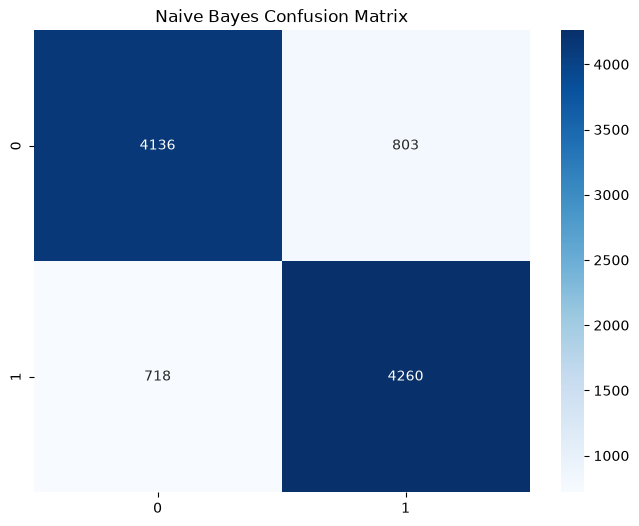

Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.86      0.88      4939
           1       0.87      0.90      0.88      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



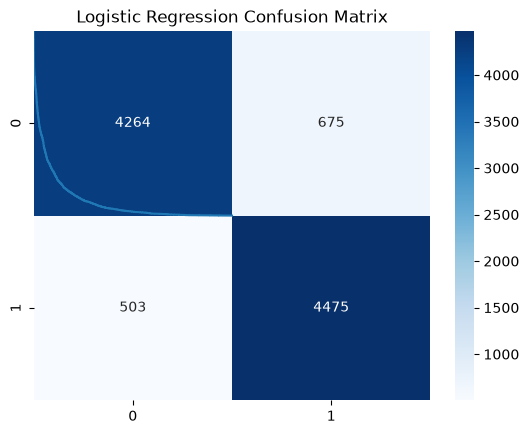

SVM
              precision    recall  f1-score   support

           0       0.89      0.86      0.88      4939
           1       0.87      0.89      0.88      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



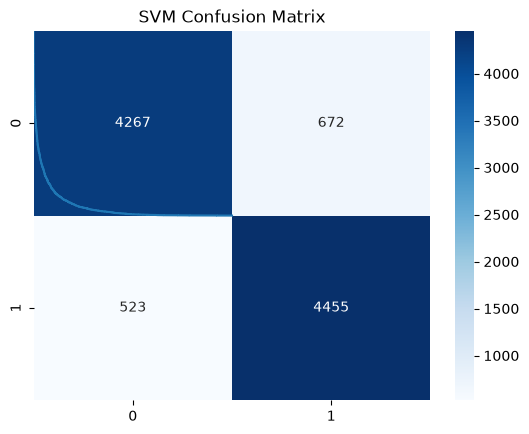

Random Forest
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      4939
           1       0.84      0.84      0.84      4978

    accuracy                           0.84      9917
   macro avg       0.84      0.84      0.84      9917
weighted avg       0.84      0.84      0.84      9917



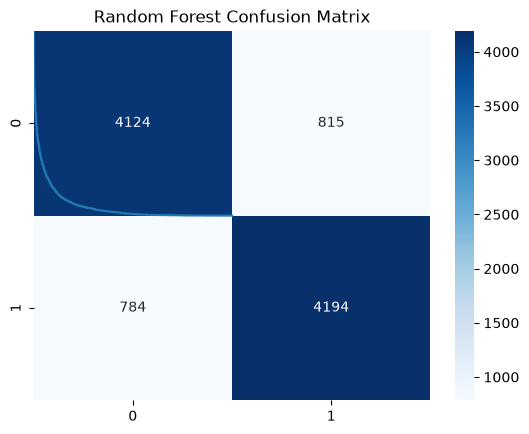

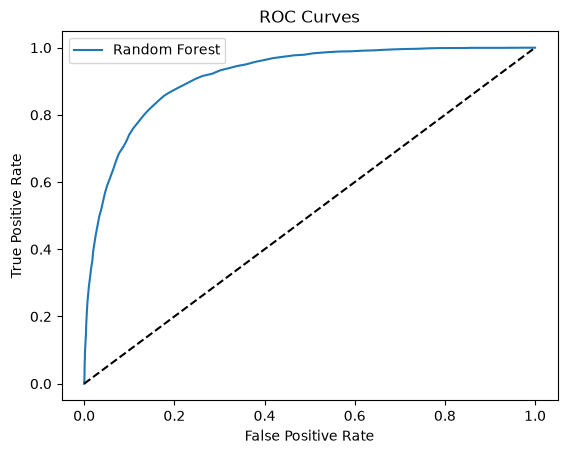

In [27]:
results = []

plt.figure(figsize=(8,6))

for name, model in models.items():

    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]
    accuracy = accuracy_score(y_test,pred)
    precision = precision_score(y_test,pred)
    recall = recall_score(y_test,pred)
    f1 = f1_score(y_test,pred)
    auc = roc_auc_score(y_test,prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ])

    print("="*60)
    print(name)
    print(classification_report(y_test,pred))

    cm = confusion_matrix(y_test,pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(name+" Confusion Matrix")
    plt.show()
    fpr,tpr,_ = roc_curve(y_test,prob)
    plt.plot(fpr,tpr,label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

#### Task 8: Performance Comparison

In [28]:
comparison = pd.DataFrame(

    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC"
    ]
)

comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,AUC
1,Logistic Regression,0.881214,0.868932,0.898955,0.883689,0.952649
2,SVM,0.879500,0.868929,0.894938,0.881742,0.948717
0,Naive Bayes,0.846627,0.841398,0.855765,0.848521,0.921657
3,Random Forest,0.838762,0.837293,0.842507,0.839892,0.915908


#### Task 9: Prediction

In [29]:
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [30]:
reviews = [
"The movie was fantastic and worth watching.",
"I regret wasting my money on this film.",
"The acting was average but the story was interesting."
]

processed = [preprocess(r) for r in reviews]
features = tfidf.transform(processed)
pred = best_model.predict(features)
prob = best_model.predict_proba(features)

for i in range(len(reviews)):
    print("="*60)
    print("Original Review:")
    print(reviews[i])
    print()
    print("Predicted Class:",
          "Positive" if pred[i]==1 else "Negative")
    print()
    print("Prediction Probability:")
    print(prob[i])

Original Review:
The movie was fantastic and worth watching.

Predicted Class: Positive

Prediction Probability:
[0.01853432 0.98146568]
Original Review:
I regret wasting my money on this film.

Predicted Class: Negative

Prediction Probability:
[0.99670246 0.00329754]
Original Review:
The acting was average but the story was interesting.

Predicted Class: Negative

Prediction Probability:
[0.89651613 0.10348387]
